<a href="https://colab.research.google.com/github/souhaylelhammadi/Introduction-l-informatique-quantique/blob/main/Informatique_Quantique_TP3_R%C3%A9gression_Multiple_Classique_et_Quantique.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Implémentation Classique
# Classe de Régression Multiple from scratch :

In [2]:
import numpy as np
import cirq
import matplotlib.pyplot as plt


In [3]:
import numpy as np
class RegressionMultiple :

  def __init__ ( self , lr =0.01 , n_iter =1000):
    self . lr = lr
    self . n_iter = n_iter
  def fit ( self , X , y ):
    n , p = X. shape
    self .w = np . zeros (p)
    self .b = 0.0
    self . losses = []
    for _ in range ( self . n_iter ):
      y_pred = X @ self .w + self .b
      error = y_pred - y
      self .w -= self . lr * ( X.T @ error ) / n
      self .b -= self . lr * np . mean ( error )
      self . losses . append ( np . mean ( error **2)/2)
  def predict ( self , X ):
    return X @ self .w + self .b


In [4]:
# Donnees synthetiques : y = 2* x1 + 3* x2 + 0.5
np . random . seed (42)
n = 100
X = np . random . randn (n , 2)
y = 2* X [: ,0] + 3* X [: ,1] + 0.5 + \
0.1* np . random . randn ( n )
# Entrainement
model = RegressionMultiple ( lr =0.01 , n_iter =500)
model . fit (X , y )
print ( f" Poids appris : { model .w}") # ~[2 , 3]
print ( f" Biais appris : { model .b:.3f}") # ~0.5
# Evaluation
y_pred = model . predict ( X )
mse = np . mean (( y_pred - y )**2)
print ( f" MSE : { mse :.4f}")

 Poids appris : [1.96603657 2.96689685]
 Biais appris : 0.493
 MSE : 0.0136


# Classe de Régression Multiple from scratch :

In [5]:
import cirq , numpy as np
def build_circuit (x , theta , qubits , n_layers ):
  circuit = cirq . Circuit ()
  n_qubits = len( qubits )
# Encodage des donnees
  for j in range ( n_qubits ):
    circuit . append (
    cirq . ry ( rads = x [ j ]). on ( qubits [ j ]))
# Couches variationnelles
  for l in range ( n_layers ):
    for j in range ( n_qubits ):
      circuit . append (
      cirq . ry ( rads = theta [l , j ]). on (
      qubits [ j ]))
  for j in range ( n_qubits - 1):
    circuit . append (
    cirq . CNOT ( qubits [ j ] , qubits [ j +1]))

  return circuit

In [6]:
def expectation_z0 ( circuit , n_qubits , sim ):
  result = sim . simulate ( circuit )
  state = result . final_state_vector
  exp_val = 0.0
  for i in range ( len ( state )):
    bit = (i >> ( n_qubits - 1)) & 1
    sign = 1 - 2 * bit # +1 si |0 > , -1 si |1 >
    exp_val += sign * abs ( state [ i ]) ** 2
  return float ( np . real ( exp_val ))
def forward (x , theta , qubits , n_layers , sim ):
  circuit = build_circuit (x , theta ,
  qubits , n_layers )

  return expectation_z0 ( circuit ,len( qubits ), sim )

In [7]:
def param_shift_grad (x , y_true , theta , qubits ,n_layers , sim ):

  shift = np . pi / 2
  grad = np . zeros_like ( theta )
  y_pred = forward (x , theta , qubits ,
  n_layers , sim )
  for l in range ( n_layers ):
    for q in range ( len ( qubits )):
      t_p = theta . copy (); t_p [l ,q ] += shift
      t_m = theta . copy (); t_m [l ,q ] -= shift
      f_p = forward (x , t_p , qubits , n_layers , sim )
      f_m = forward (x , t_m , qubits , n_layers , sim )
      grad [l ,q] = ( y_pred - y_true )*( f_p - f_m )
  return grad

In [11]:
sim = cirq.Simulator()

qubits = cirq.LineQubit.range(2)   # 2 qubits
n_layers = 2

theta = np.random.randn(n_layers, 2) * 0.1
lr = 0.1

losses = []

for epoch in range(100):

    total_grad = np.zeros_like(theta)
    loss = 0.0

    for i in range(len(X)):

        # forward pass
        y_pred = forward(X[i], theta, qubits, n_layers, sim)

        # loss MSE
        loss += (y_pred - y_norm[i]) ** 2

        # gradient Parameter Shift
        g = param_shift_grad(
            X[i], y_norm[i],
            theta, qubits, n_layers, sim
        )

        total_grad += g

    # moyenne
    loss /= len(X)
    total_grad /= len(X)

    # update (gradient descent)
    theta -= lr * total_grad

    losses.append(loss)

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.4f}")


Epoch 0, Loss: 1.0420
Epoch 10, Loss: 0.6682
Epoch 20, Loss: 0.3277
Epoch 30, Loss: 0.3092
Epoch 40, Loss: 0.3086
Epoch 50, Loss: 0.3086
Epoch 60, Loss: 0.3086
Epoch 70, Loss: 0.3086
Epoch 80, Loss: 0.3086
Epoch 90, Loss: 0.3086


# Exercice

In [12]:
np.random.seed(0)

n = 120
X = np.random.randn(n, 3)

y = (
    X[:,0]
    - 2*X[:,1]
    + 0.5*X[:,2]
    + 0.1*np.random.randn(n)
)

# normalisation dans [-1,1] (important pour <Z>)
y_norm = y / np.max(np.abs(y))

In [13]:
def build_circuit(x, theta, qubits, n_layers):
    circuit = cirq.Circuit()

    # -------- Encodage données (Angle Encoding)
    for j in range(3):
        circuit.append(cirq.ry(x[j]).on(qubits[j]))

    # -------- Ansatz variationnel
    for l in range(n_layers):

        # rotations paramétrées
        for j in range(3):
            circuit.append(cirq.ry(theta[l,j]).on(qubits[j]))

        # intrication CNOT chaîne
        circuit.append(cirq.CNOT(qubits[0], qubits[1]))
        circuit.append(cirq.CNOT(qubits[1], qubits[2]))

    return circuit


In [14]:
def expectation_z0(circuit, sim):
    result = sim.simulate(circuit)
    state = result.final_state_vector

    exp = 0.0

    for i, amp in enumerate(state):
        bit0 = (i >> 2) & 1   # premier qubit
        sign = 1 - 2*bit0
        exp += sign * abs(amp)**2

    return exp


def forward(x, theta, qubits, n_layers, sim):
    c = build_circuit(x, theta, qubits, n_layers)
    return expectation_z0(c, sim)

In [15]:
def param_shift_grad(x, y_true, theta, qubits, n_layers, sim):

    shift = np.pi/2
    grad = np.zeros_like(theta)

    y_pred = forward(x, theta, qubits, n_layers, sim)

    for l in range(n_layers):
        for q in range(3):

            t_p = theta.copy()
            t_m = theta.copy()

            t_p[l,q] += shift
            t_m[l,q] -= shift

            f_p = forward(x, t_p, qubits, n_layers, sim)
            f_m = forward(x, t_m, qubits, n_layers, sim)

            grad[l,q] = (y_pred - y_true) * (f_p - f_m)

    return grad

In [16]:
sim = cirq.Simulator()
qubits = cirq.LineQubit.range(3)

n_layers = 2
theta = np.random.randn(n_layers, 3) * 0.1
lr = 0.15

losses = []

for epoch in range(80):

    total_grad = np.zeros_like(theta)
    loss = 0

    for i in range(n):

        y_pred = forward(X[i], theta, qubits, n_layers, sim)

        loss += (y_pred - y_norm[i])**2

        total_grad += param_shift_grad(
            X[i], y_norm[i],
            theta, qubits, n_layers, sim
        )

    loss /= n
    total_grad /= n

    theta -= lr * total_grad

    losses.append(loss)

    if epoch % 10 == 0:
        print(f"Epoch {epoch}  Loss = {loss:.4f}")

Epoch 0  Loss = 0.7083
Epoch 10  Loss = 0.5418
Epoch 20  Loss = 0.2994
Epoch 30  Loss = 0.1756
Epoch 40  Loss = 0.1455
Epoch 50  Loss = 0.1396
Epoch 60  Loss = 0.1380
Epoch 70  Loss = 0.1372


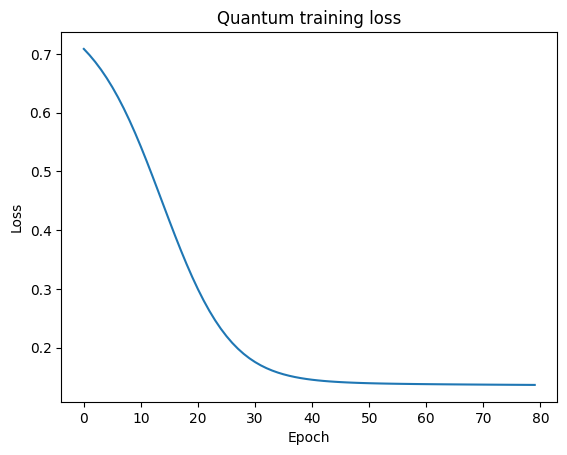

In [17]:
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Quantum training loss")
plt.show()

In [18]:
w = np.linalg.pinv(X) @ y
y_classic = X @ w

print("\nPoids classiques estimés :", w)

pred_quantum = np.array([
    forward(X[i], theta, qubits, n_layers, sim)
    for i in range(n)
])

print("MSE quantique :", np.mean((pred_quantum - y_norm)**2))
print("MSE classique :", np.mean((y_classic - y)**2))



Poids classiques estimés : [ 1.01184427 -2.00095432  0.51724906]
MSE quantique : 0.13660633291221747
MSE classique : 0.009250064851687341


#  Résumé — Régression Multiple Quantique (QML)

##  Objectif
Prédire une valeur continue y à partir de plusieurs variables x1, x2, x3  
en utilisant un **circuit quantique paramétré** au lieu d’un modèle linéaire classique.

---

##  Étape 1 — Encodage des données

Chaque feature est transformée en angle :

RY(xj)

Donc :

|0⟩ → RY(x1)  
|0⟩ → RY(x2)  
|0⟩ → RY(x3)

👉 Les données classiques sont encodées dans les qubits.

---

##  Étape 2 — Ansatz (partie entraînable)

On ajoute des paramètres θ :

RY(θ) + CNOT

Rôle :
- RY(θ) → paramètres à apprendre (comme les poids w)
- CNOT → corrélations entre variables (intrication)

 Permet au modèle d’être plus puissant et non linéaire.

---

##  Étape 3 — Prédiction

On mesure l’observable Z sur le premier qubit :

ŷ = ⟨Z₀⟩

La sortie est toujours dans [-1, 1]

👉 on normalise y avant l’apprentissage.

---

##  Étape 4 — Gradient quantique

On ne peut pas dériver directement.

On utilise la Parameter Shift Rule :

∂f/∂θ = [f(θ+π/2) − f(θ−π/2)] / 2

👉 on exécute le circuit 2 fois pour obtenir le gradient exact.

---

##  Étape 5 — Entraînement

Descente de gradient classique :

theta = theta − lr × grad

Répéter :
1. prédiction
2. loss (MSE)
3. gradient
4. mise à jour θ

---

#  Résultat attendu

 Loss diminue  
 MSE quantique proche du classique  
 θ apprend la relation entre x et y  

---

##  Idée clé

Classique :      y = wᵀx + b  
Quantique :      y = ⟨Z⟩ d’un circuit paramétré

 On remplace les poids par des rotations quantiques.
